## Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb

## Load Dataset

In [2]:
# Muat dataset
diamonds = sns.load_dataset("diamonds")
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Data Preprocessing

In [3]:
# Hapus baris dengan nilai 0 pada kolom x, y, atau z
diamonds = diamonds[(diamonds[['x', 'y', 'z']] != 0).all(axis=1)]

# Konversi variabel kategorikal ke kode ordinal
# Cut
diamonds['cut'] = pd.Categorical(
    diamonds['cut'], 
    categories=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], 
    ordered=True
)
diamonds['cut_code'] = diamonds['cut'].cat.codes

# Color
diamonds['color'] = pd.Categorical(
    diamonds['color'], 
    categories=['J', 'I', 'H', 'G', 'F', 'E', 'D'], 
    ordered=True
)
diamonds['color_code'] = diamonds['color'].cat.codes

# Clarity
diamonds['clarity'] = pd.Categorical(
    diamonds['clarity'], 
    categories=['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'], 
    ordered=True
)
diamonds['clarity_code'] = diamonds['clarity'].cat.codes

# Hapus kolom kategorikal asli
diamonds = diamonds.drop(['cut', 'color', 'clarity'], axis=1)

## Feature and Target

In [4]:
X = diamonds.drop('price', axis=1)
y = diamonds['price']

## Split Dataset

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

## Model XGBoost Training

In [6]:
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

## Predict and evaluation

In [8]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
print(f"RMSE: {rmse}")

mape = (abs(y_test - y_pred) / y_test).mean() * 100
print(f"MAPE: {mape:.2f}%")

RMSE: 533.969390546936
MAPE: 7.04%


## Visualisasi hasil prediksi

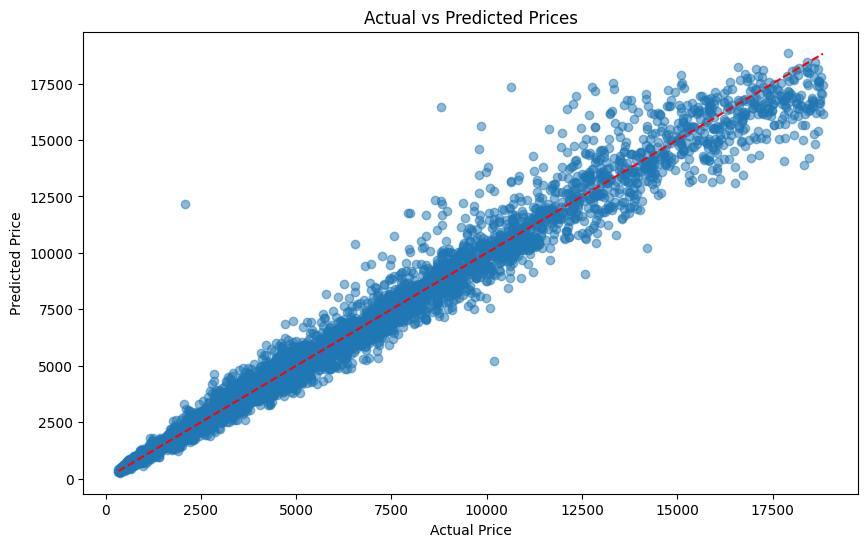

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.show()